In [43]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

In [44]:
from GraphSimulation import (
    TripartiteGraph,
    GreedyStrategy, RankStrategy
)

In [45]:
n_Inodes = 18
n_Lnodes = 15
n_Rnodes = 20

INT_MAX = int(1e6)
OPTIMAL = min(n_Lnodes, n_Inodes, n_Rnodes)

In [46]:
def generate_varNodes(inode_ids, n_Lnodes, n_Inodes, n_Rnodes, shuffle=True, seed= None):
    rand_gen = np.random.default_rng(seed)
    nodes = []

    # Generate L nodes
    for t in range(n_Lnodes):
        k = rand_gen.integers(1, n_Inodes + 1)
        candidates = rand_gen.choice(inode_ids, size=k, replace=False).tolist()
        nodes.append(("L", t, candidates))

    # Generate R nodes
    for t in range(n_Rnodes):
        k = rand_gen.integers(1, n_Inodes + 1)
        candidates = rand_gen.choice(inode_ids, size=k, replace=False).tolist()
        nodes.append(("R", t, candidates))

    if shuffle: rand_gen.shuffle(nodes)
    return nodes

def simulate_online(graph: TripartiteGraph, node_order):
    for node_type, time, candidates in node_order:
        if node_type == "L":
            graph.add_Lnode(time, candidates)
        else:
            graph.add_Rnode(time, candidates)
    return graph.matches

In [47]:
def run_experiment(strategy, runs=100, 
                n_inodes= n_Inodes, n_lnodes=n_Lnodes, n_rnodes=n_Rnodes, 
                shuffle=True, seed:int|None= None):
    results_online = []
    rand_gen = np.random.default_rng(seed)

    pbar = tqdm(range(runs), desc=f'Simulating: {strategy.__class__.__name__}')
    for _ in pbar:
        # Create the Graph
        g = TripartiteGraph(strategy, n_inodes)
        inode_ids = list(g.Inodes.keys())

        # Generate the nodes
        order_seed = rand_gen.integers(INT_MAX)
        node_order = generate_varNodes(inode_ids,
                        n_lnodes, n_inodes, n_rnodes, shuffle=shuffle, seed= order_seed)

        # Online
        matches_online = simulate_online(g, node_order)
        results_online.append(matches_online)
    return results_online

In [48]:
RUN_SEED = 42
greedy_res = run_experiment(GreedyStrategy(), seed= RUN_SEED)
rank_res = run_experiment(RankStrategy(), seed= RUN_SEED)

Simulating: RankStrategy: 100%|██████████| 100/100 [00:00<00:00, 1194.98it/s]


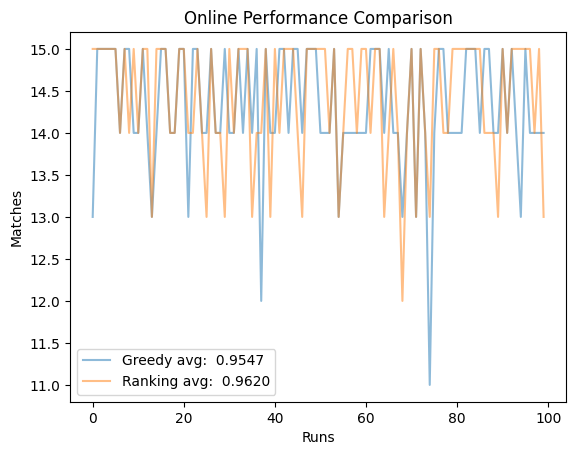

In [49]:
def plot_results(greedy_res, rank_res, optimal= OPTIMAL):
    plt.plot(greedy_res, alpha=0.5, label=f"Greedy avg: {np.average(greedy_res) / optimal: .4f}")
    plt.plot(rank_res, alpha=0.5, label=f"Ranking avg: {np.average(rank_res) / optimal: .4f}")

    plt.title("Online Performance Comparison")
    plt.xlabel("Runs")
    plt.ylabel("Matches")

    plt.legend()
    plt.show()

plot_results(greedy_res, rank_res)